In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score
import seaborn as sns

plt.rcParams.update({
    "font.size": 10,        # default text
    "axes.titlesize": 12,   # title
    "axes.labelsize": 10,   # axis labels
    "xtick.labelsize": 10,  # x tick labels
    "ytick.labelsize": 10,  # y tick labels
    "legend.fontsize": 10
})

result_dir = "/mnt/oss_nanhu100TB/default/zjq/results/SpecFun/result"

In [ ]:
dataset = "desi-sv1" #desi-sv1
# mods = ["sp", "im", "ph", "im+ph", "sp+im", "sp+ph", "sp+im+ph"]
mods = ["ph", "im+ph", "sp+im+ph"]
targets = ["type"]

mask_types = ["zq", "spec_snr_mean", "spec_snr_median"][:1]
metrics_dict = {mask_type: {mod: {"cut": [],"acc": [],"macro_f1": [],"weighted_f1": 
                                  [],"per_class": {},"cm": [],"classes_str": []
                                  }for mod in mods}for mask_type in mask_types}

In [ ]:
cut_ids = range(5)
mask_type = "zq"
fig, axes = plt.subplots(len(mods), len(cut_ids), figsize=(5 * len(cut_ids), 4 * len(mods)))

for i, mod in enumerate(mods):
    for j, cut in enumerate(cut_ids):
        cm = metrics_dict[mask_type][mod]["cm"][j]
        classes_str = metrics_dict[mask_type][mod]["classes_str"][j]
        precisions = [metrics_dict[mask_type][mod]["per_class"][cls]["precision"][j] for cls in classes_str]
        precision_str = ", ".join([f"{cls}: {p:.2f}" for cls, p in zip(classes_str, precisions)])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i, j], cbar=False, xticklabels=classes_str, yticklabels=classes_str)
        axes[i, j].set_title(f'{mod} - Cut {cut}\nPrecisions: {precision_str}')
        axes[i, j].set_xlabel('Predicted')
        axes[i, j].set_ylabel('True')

plt.tight_layout()
plt.show()

In [9]:
mask_types = ["zq", "spec_snr_mean", "spec_snr_median"][:1]
cut_ids = range(5)

metrics_dict = {
    mask_type: {
        mod: {
            "cut": [],
            "acc": [],
            "macro_f1": [],
            "weighted_f1": [],
            "per_class": {},
            "cm": [],
            "classes_str": []
        }
        for mod in mods
    }
    for mask_type in mask_types
}

for mask_type in mask_types:
    for i in cut_ids:
        mask = f"{mask_type}_cut{i}"
        for mod in mods:
            # ---- file path ----
            if i == 0:
                pred_file = os.path.join(
                    result_dir, f"{dataset}", "class",
                    f"{dataset}_{mod}_class_type.npz"
                )
            elif mask_type == "zq":
                pred_file = os.path.join(
                    result_dir, f"{dataset}", "class", "zq_cut",
                    f"{dataset}_{mod}_class_type_{mask}.npz"
                )
            elif "spec_snr" in mask_type:
                pred_file = os.path.join(
                    result_dir, f"{dataset}", "class", "spec_snr",
                    f"{dataset}_{mod}_class_type_{mask}.npz"
                )
            else:
                raise ValueError(f"Unknown mask type: {mask_type}")

            data = np.load(pred_file, allow_pickle=True)
            y_true = data["test_true"]
            y_pred = data["test_pred"]
            classes = data["classes"]
            classes_str = [str(c) for c in classes]

            # ---- global metrics ----
            acc = accuracy_score(y_true, y_pred)
            macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
            weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

            cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
            metrics_dict[mask_type][mod]["cut"].append(i)
            metrics_dict[mask_type][mod]["acc"].append(acc)
            metrics_dict[mask_type][mod]["macro_f1"].append(macro_f1)
            metrics_dict[mask_type][mod]["weighted_f1"].append(weighted_f1)
            metrics_dict[mask_type][mod]["cm"].append(cm)
            metrics_dict[mask_type][mod]["classes_str"].append(classes_str)

            # ---- per-class metrics ----
            for idx, cls in enumerate(classes_str):
                tp = cm[idx, idx]
                true_cls = cm[idx, :].sum()
                pred_cls = cm[:, idx].sum()
                recall = tp / true_cls if true_cls > 0 else 0.0
                precision = tp / pred_cls if pred_cls > 0 else 0.0
                f1_cls = (
                    2 * precision * recall / (precision + recall)
                    if (precision + recall) > 0 else 0.0
                )

                if cls not in metrics_dict[mask_type][mod]["per_class"]:
                    metrics_dict[mask_type][mod]["per_class"][cls] = {
                        "recall": [],
                        "precision": [],
                        "f1": []
                    }

                metrics_dict[mask_type][mod]["per_class"][cls]["recall"].append(recall)
                metrics_dict[mask_type][mod]["per_class"][cls]["precision"].append(precision)
                metrics_dict[mask_type][mod]["per_class"][cls]["f1"].append(f1_cls)

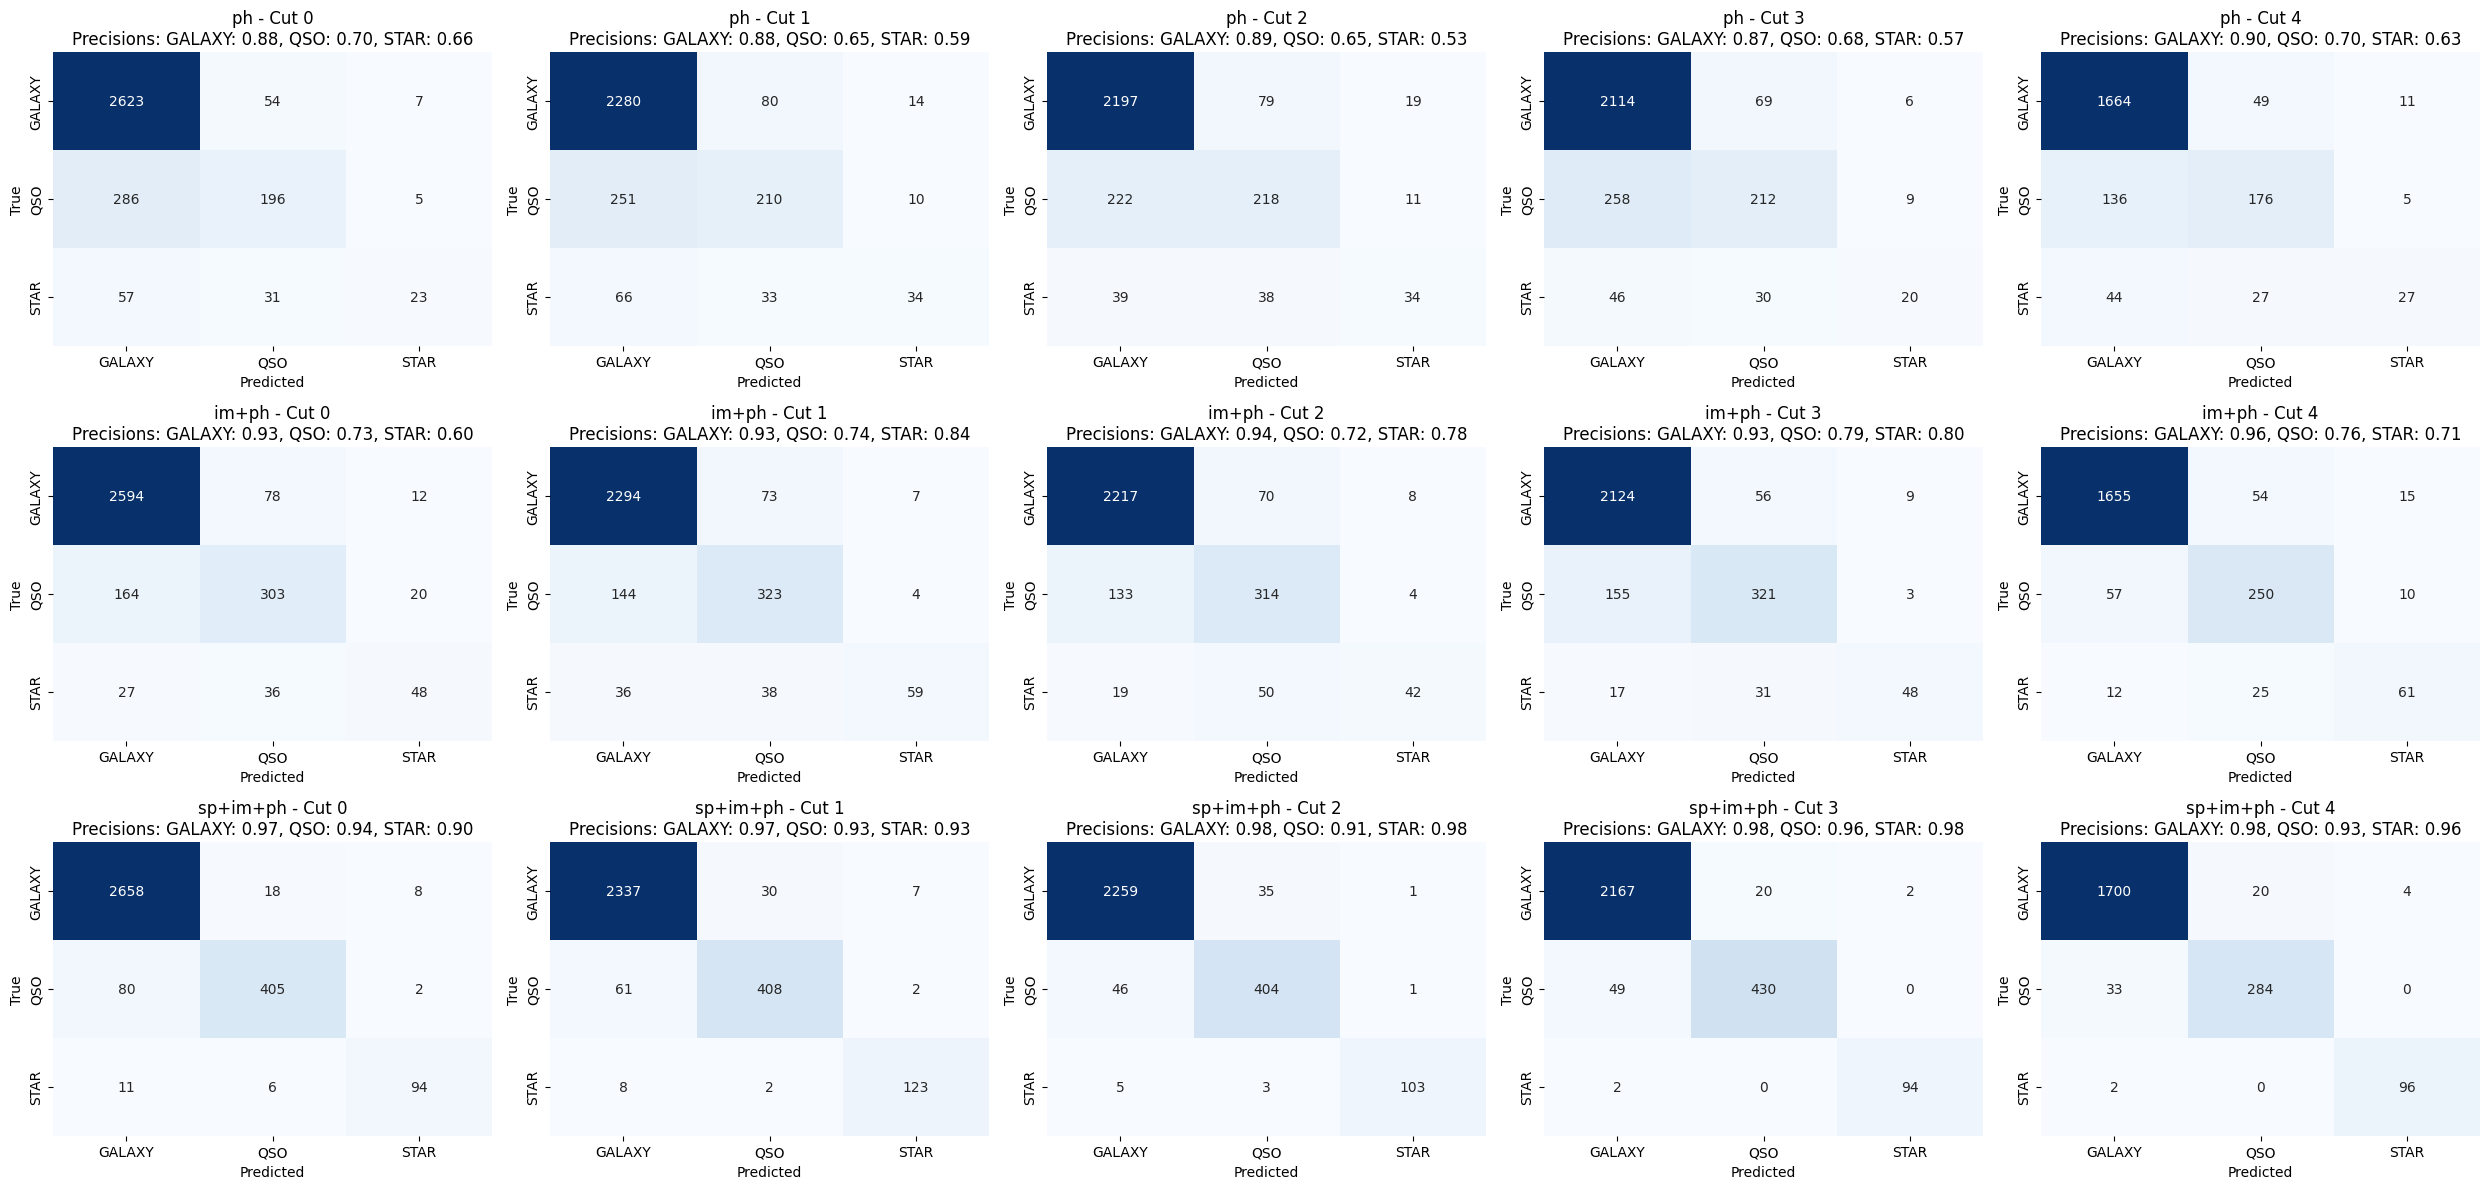